<a href="https://colab.research.google.com/github/Roqaya-muhmd/Deep_learning_with_CV/blob/main/flood_water_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Kaggle Competition Data

To load data from Kaggle, follow these steps:

### Step 1: Install the Kaggle API Client

Run the following command to install the `kaggle` library.

In [15]:
!pip install kaggle

### Step 2: Set up Kaggle API Credentials

1.  Go to Kaggle and log in.
2.  Click on your profile picture in the top right corner and select "My Account".
3.  Scroll down to the "API" section and click "Create New API Token". This will download a `kaggle.json` file to your computer.
4.  Open the `kaggle.json` file. It will contain your username and API key in the following format:
    ```json
    {"username":"YOUR_KAGGLE_USERNAME","key":"YOUR_KAGGLE_KEY"}
    ```
5.  In Colab, go to the left panel, click on the "🔑 Secrets" icon.
6.  Click "Add new secret".
7.  Set the "Name" field to `KAGGLE_USERNAME` and the "Value" field to your Kaggle username from the `kaggle.json` file.
8.  Click "Add new secret" again. Set the "Name" field to `KAGGLE_KEY` and the "Value" field to your Kaggle API key from the `kaggle.json` file.

After setting up the secrets, run the following cell to configure the Kaggle API client:

In [16]:
# Import necessary libraries
from google.colab import userdata
import os

# Retrieve secrets
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

# Create .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle', exist_ok=True)

# Write kaggle.json file
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')

# Set permissions for kaggle.json
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API credentials set up successfully!")

Kaggle API credentials set up successfully!


### Step 3: Download Competition Data

Now you can download data for a specific Kaggle competition. You'll need the competition name, which can be found in the URL of the competition page (e.g., `house-prices-advanced-regression-techniques`).

Replace `'your-competition-name'` with the actual competition name below and run the cell. This will download the data into the current working directory.

In [17]:
# Extract the competition ID from the URL
competition_url = 'https://www.kaggle.com/competitions/flood-image-segmentation-ml-4-im-2025-2026'
competition_name = competition_url.split('/')[-1]
!kaggle competitions download -c {competition_name}

100% 1.42G/1.42G [00:20<00:00, 72.6MB/s]



### Step 4: Unzip and Load Data into Pandas

Kaggle data is often downloaded as a `.zip` file. You'll need to unzip it and then load the relevant CSV files into pandas DataFrames.

Files downloaded:
flood-image-segmentation-ml-4-im-2025-2026.zip	sample_data

Extracted 'flood-image-segmentation-ml-4-im-2025-2026.zip'. Files in current directory:
flood-image-segmentation-ml-4-im-2025-2026.zip	sample_data  Testing  Training

Found 3112 images in 'Training/Images'. First 5: ['aug_259_3541.png', 'aug_96_5172.png', 'aug_102_3773.png', 'aug_64_9426.png', 'aug_244_2374.png']

Loading and displaying a sample training image from: Training/Images/aug_259_3541.png


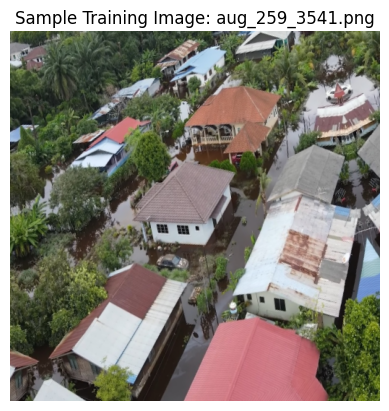


Found 289 images in 'Testing/Images'. First 5: ['063.png', '149.png', '220.png', '081.png', '207.png']

Loading and displaying a sample testing image from: Testing/Images/063.png


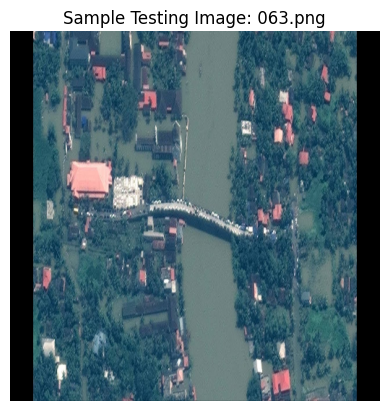


For image datasets, you would typically use libraries like TensorFlow or PyTorch to create datasets for model training, rather than loading all images into pandas DataFrames.


In [18]:
import zipfile
import os
from PIL import Image
import matplotlib.pyplot as plt

# List files in the current directory to see what was downloaded
print("Files downloaded:")
!ls

# Unzip the downloaded file
zip_file_name = f'{competition_name}.zip'
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"\nExtracted '{zip_file_name}'. Files in current directory:")
    !ls
else:
    print(f"\nError: '{zip_file_name}' not found. Please check competition name and download status.")

# --- Handling Image Data ---

train_image_dir = 'Training/Images'
test_image_dir = 'Testing/Images'

# Check if the directories exist
if os.path.exists(train_image_dir):
    train_images = os.listdir(train_image_dir)
    print(f"\nFound {len(train_images)} images in '{train_image_dir}'. First 5: {train_images[:5]}")

    # Example: Load and display one training image
    if train_images:
        sample_image_path = os.path.join(train_image_dir, train_images[0])
        print(f"\nLoading and displaying a sample training image from: {sample_image_path}")
        try:
            img = Image.open(sample_image_path)
            plt.imshow(img)
            plt.title(f'Sample Training Image: {train_images[0]}')
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error loading image {sample_image_path}: {e}")
else:
    print(f"\nError: Training image directory '{train_image_dir}' not found.")

if os.path.exists(test_image_dir):
    test_images = os.listdir(test_image_dir)
    print(f"\nFound {len(test_images)} images in '{test_image_dir}'. First 5: {test_images[:5]}")

    # Example: Load and display one testing image
    if test_images:
        sample_image_path = os.path.join(test_image_dir, test_images[0])
        print(f"\nLoading and displaying a sample testing image from: {sample_image_path}")
        try:
            img = Image.open(sample_image_path)
            plt.imshow(img)
            plt.title(f'Sample Testing Image: {test_images[0]}')
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error loading image {sample_image_path}: {e}")
else:
    print(f"\nError: Testing image directory '{test_image_dir}' not found.")

print("\nFor image datasets, you would typically use libraries like TensorFlow or PyTorch to create datasets for model training, rather than loading all images into pandas DataFrames.")

In [19]:
# Common
import tensorflow as tf
from glob import glob
import numpy as np

# Data
from sklearn.model_selection import train_test_split
import cv2

# Data visualization
import matplotlib.pyplot as plt

# Model
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from keras.optimizers import Adam

# Metrics
from tensorflow.keras.metrics import *

In [20]:
import os
from glob import glob
import cv2
import numpy as np

def load_image_and_mask_paths(image_dir, mask_dir):
    image_paths = sorted(glob(os.path.join(image_dir, '*.png')))
    mask_paths = sorted(glob(os.path.join(mask_dir, '*.png')))

    print(f"Found {len(image_paths)} image paths in {image_dir}")
    print(f"Found {len(mask_paths)} mask paths in {mask_dir}")
    if len(image_paths) > 0:
        print(f"Sample image path: {image_paths[0]}")
    if len(mask_paths) > 0:
        print(f"Sample mask path: {mask_paths[0]}")

    paired_image_paths = []
    paired_mask_paths = []

    image_basenames = {os.path.basename(p): p for p in image_paths}

    for mask_path in mask_paths:
        mask_basename = os.path.basename(mask_path)

        if mask_basename in image_basenames:
            image_path = image_basenames[mask_basename]
            paired_image_paths.append(image_path)
            paired_mask_paths.append(mask_path)
        else:
            print(f"Warning: Mask file {mask_basename} has no matching image in {image_dir}. Skipping.")

    print(f"Successfully paired {len(paired_image_paths)} images and {len(paired_mask_paths)} masks.")
    return paired_image_paths, paired_mask_paths

def preprocess_image(image_path, size, color_mode='rgb'):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3) # Decode as 3 channels for RGB
    img = tf.image.resize(img, [size, size])
    img = tf.cast(img, tf.float32) / 255.0 # Normalize
    return img

def preprocess_mask(mask_path, size):
    msk = tf.io.read_file(mask_path)
    msk = tf.image.decode_png(msk, channels=1) # Decode as 1 channel for grayscale mask
    msk = tf.image.resize(msk, [size, size])
    msk = tf.cast(msk, tf.float32) / 255.0 # Normalize
    msk = tf.where(msk > 0.5, 1.0, 0.0) # Ensure binary mask
    return msk

def load_dataset(image_path, mask_path, size):
    img = preprocess_image(image_path, size)
    msk = preprocess_mask(mask_path, size)
    return img, msk

In [21]:
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    return img, mask


In [22]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

size = 256 # Define the image size

# Load only paths to images and masks
all_image_paths, all_mask_paths = load_image_and_mask_paths(
    image_dir='/content/Training/Images',
    mask_dir='/content/Training/Masks'
)

# Split paths into training and validation sets
train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(
    all_image_paths, all_mask_paths, test_size=0.2, random_state=42
)

print(f"Training images: {len(train_image_paths)}, Validation images: {len(val_image_paths)}")

# Define the expected output signature for the dataset elements
output_signature=(
    tf.TensorSpec(shape=(size, size, 3), dtype=tf.float32), # Image: (height, width, channels)
    tf.TensorSpec(shape=(size, size, 1), dtype=tf.float32)  # Mask: (height, width, channels)
)

# Create tf.data.Dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_mask_paths))
train_dataset = train_dataset.map(lambda img_path, msk_path: load_dataset(img_path, msk_path, size),
                                  num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(4).prefetch(1)

# Create tf.data.Dataset for validation
val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_mask_paths))
val_dataset = val_dataset.map(lambda img_path, msk_path: load_dataset(img_path, msk_path, size),
                                num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(4).prefetch(1)

print("tf.data.Dataset for training and validation created successfully!")

# You can verify a batch like this (optional, might still consume some memory for one batch):
# for image_batch, mask_batch in train_dataset.take(1):
#     print(f"Shape of one image batch: {image_batch.shape}")
#     print(f"Shape of one mask batch: {mask_batch.shape}")
#     break

Found 3112 image paths in /content/Training/Images
Found 3112 mask paths in /content/Training/Masks
Sample image path: /content/Training/Images/aug_0_1456.png
Sample mask path: /content/Training/Masks/aug_0_1456.png
Successfully paired 3112 images and 3112 masks.
Training images: 2489, Validation images: 623
tf.data.Dataset for training and validation created successfully!


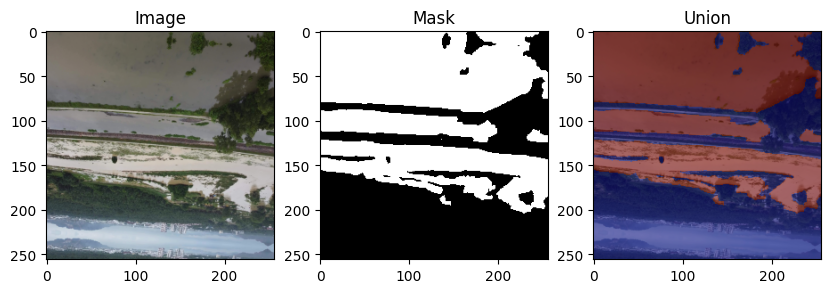

In [23]:
import matplotlib.pyplot as plt

# Get one batch from the training dataset
for image_batch, mask_batch in train_dataset.take(1):
    break

fig, ax = plt.subplots(1,3, figsize=(10,5))

i = np.random.randint(0, image_batch.shape[0])
ax[0].imshow(image_batch[i])
ax[0].set_title('Image')
ax[1].imshow(tf.squeeze(mask_batch[i]), cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(image_batch[i])
ax[2].imshow(tf.squeeze(mask_batch[i]), alpha=0.5, cmap='jet')
ax[2].set_title('Union')
plt.show()

In [24]:
import tensorflow as tf

def conv_block(x, filters, dropout=0.0):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout)(x)

    return x


def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = tf.keras.layers.MaxPooling2D((2, 2))(c)
    return c, p


def decoder_block(x, skip, filters):
    x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_optimized_unet(input_shape=(256, 256, 3)):
    inputs = tf.keras.layers.Input(input_shape)

    # Encoder (lighter)
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    # Bottleneck (with dropout)
    b = conv_block(p4, 512, dropout=0.3)

    # Decoder
    d1 = decoder_block(b, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(d4)

    return tf.keras.Model(inputs, outputs, name="Optimized_U-Net")

In [25]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [26]:
model = build_optimized_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [27]:
model.summary()

Model: "Optimized_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_23[0][0] 

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_binary_io_u",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - binary_io_u_1: 0.6947 - loss: 0.6120 - precision_1: 0.8232 - recall_1: 0.8165

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_binary_io_u available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to best_model.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 115s 169ms/step - binary_io_u_1: 0.7120 - loss: 0.5768 - precision_1: 0.8373 - recall_1: 0.8262 - val_binary_io_u_1: 0.7531 - val_loss: 0.4914 - val_precision_1: 0.8584 - val_recall_1: 0.8600 - learning_rate: 1.0000e-04
Epoch 2/50
622/623 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - binary_io_u_1: 0.7421 - loss: 0.5141 - precision_1: 0.8589 - recall_1: 0.8452
Epoch 2: finished saving model to best_model.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - binary_io_u_1: 0.7496 - loss: 0.5012 - precision_1: 0.8628 - recall_1: 0.8510 - val_binary_io_u_1: 0.7505 - val_loss: 0.4781 - val_precision_1: 0.8983 - val_recall_1: 0.8203 - learning_rate: 1.0000e-04
Epoch 3/50
622/623 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - binary_io_u_1: 0.7714 - loss: 0.4602 - precision_1: 0.8775 - recall_1: 0.8645
Epoch 3: finished saving model to best_model.keras
623/623 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - binary_io_u_1: 0.7714 - loss: 0.457

### Evaluate Model on Test Data: Classification Report

First, let's prepare the test dataset and make predictions.

In [ ]:
from sklearn.metrics import classification_report

# Define test directories
test_image_dir = '/content/Testing/Images'
test_mask_dir = '/content/Testing/Masks' # Assuming test masks are available for evaluation

# Load test image and mask paths
test_image_paths, test_mask_paths = load_image_and_mask_paths(
    image_dir=test_image_dir,
    mask_dir=test_mask_dir
)

# Create tf.data.Dataset for testing (no augmentation for testing)
test_dataset = tf.data.Dataset.from_tensor_slices((test_image_paths, test_mask_paths))
test_dataset = test_dataset.map(lambda img_path, msk_path: load_dataset(img_path, msk_path, size),
                               num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(4).prefetch(1)

print("Test tf.data.Dataset created successfully!")

In [ ]:
# Make predictions on the test dataset
predictions = model.predict(test_dataset)

# Get true masks from the test dataset
true_masks = []
for _, mask_batch in test_dataset:
    true_masks.append(mask_batch)
true_masks = np.concatenate(true_masks, axis=0);

# Threshold predictions to get binary masks (0 or 1)
predicted_masks = (predictions > 0.5).astype(np.uint8)

# Flatten the masks for classification report (pixel-wise comparison)
y_true_flat = true_masks.flatten()
y_pred_flat = predicted_masks.flatten()

# Generate classification report
print("\nClassification Report for Test Set (Pixel-wise):\n")
print(classification_report(y_true_flat, y_pred_flat, target_names=['Background', 'Flood']))

### Plot Training and Validation Loss

Let's visualize how the training and validation loss evolved over the epochs.

In [ ]:
import matplotlib.pyplot as plt

# Get loss and validation loss from history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1);

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()